# Исследование стоимости подержанных автомобилей Toyota Corolla
## Предсказание цены с помощью моделей линейной регрессии

In [22]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("vishakhdapat/price-of-used-toyota-corolla-cars")

print("Path to dataset files:", path)

files = os.listdir(path)
print("Files in directory:", files)

csv_files = [f for f in files if f.endswith('.csv')]
full_path = os.path.join(path, csv_files[0])
df = pd.read_csv(full_path)
display(df.head())
display(df.info())

Using Colab cache for faster access to the 'price-of-used-toyota-corolla-cars' dataset.
Path to dataset files: /kaggle/input/price-of-used-toyota-corolla-cars
Files in directory: ['ToyotaCorolla.csv']


,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Id                 1436 non-null   int64 
 1   Model              1436 non-null   object
 2   Price              1436 non-null   int64 
 3   Age_08_04          1436 non-null   int64 
 4   Mfg_Month          1436 non-null   int64 
 5   Mfg_Year           1436 non-null   int64 
 6   KM                 1436 non-null   int64 
 7   Fuel_Type          1436 non-null   object
 8   HP                 1436 non-null   int64 
 9   Met_Color          1436 non-null   int64 
 10  Color              1436 non-null   object
 11  Automatic          1436 non-null   int64 
 12  CC                 1436 non-null   int64 
 13  Doors              1436 non-null   int64 
 14  Cylinders          1436 non-null   int64 
 15  Gears              1436 non-null   int64 
 16  Quarterly_Tax      1436 non-null   int64 


None

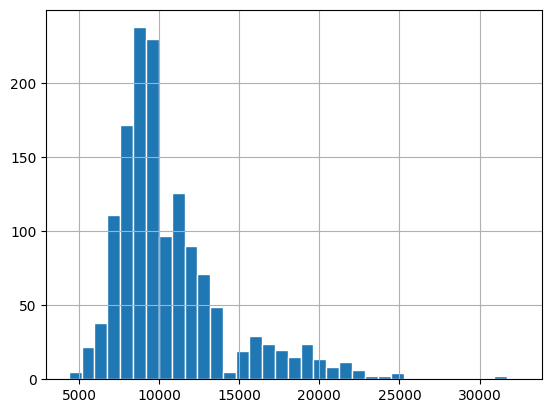

In [23]:
import matplotlib.pyplot as plt

df['Price'].hist(bins=35, edgecolor='white')
plt.show()

In [24]:
print('Статистика по строковым столбцам, чтобы знать как их преобразовывать:')
display(df.describe(include='object'))

Статистика по строковым столбцам, чтобы знать как их преобразовывать:


,Model,Fuel_Type,Color
count,1436,1436,1436
unique,319,3,10
top,TOYOTA Corolla 1.6 16V HATCHB LINEA TERRA 2/3-...,Petrol,Grey
freq,109,1264,301


## 1. Первичный анализ данных (EDA) и предобработка
* **Описание данных:** Датасет содержит характеристики автомобилей Toyota Corolla. Целевая переменная — `Price`.
* **Предобработка:** В данных отсутствуют пропуски.
* **Выводы EDA:** Распределение цены имеет правостороннюю асимметрию с редкими дорогими экземплярами (свыше 30,000). Основные факторы, вероятно влияющие на цену: возраст, пробег и модель.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df_processed = df.copy()
basic_colors = ['Grey', 'White', 'Black']
df_processed['Is_Basic_Color'] = df_processed['Color'].apply(lambda x: 1 if x in basic_colors else 0)

df_processed = df_processed.drop(['Id', 'Model', 'Color'], axis=1)

df_processed = pd.get_dummies(df_processed, columns=['Fuel_Type'], drop_first=True)

X = df_processed.drop('Price', axis=1)
y = df_processed['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Данные готовы! Обучение: {X_train_scaled.shape[0]} авто, Тест: {X_test_scaled.shape[0]} авто.")

Данные готовы! Обучение: 1148 авто, Тест: 288 авто.


## 3. Работа с признаками (Feature Engineering)
В этом разделе была проведена оптимизация признакового пространства:
* **Удаление:** Мы удалили признаки `Id` и `Model`. Идентификатор не несет физического смысла, а признак `Model` содержал более 300 уникальных значений, что привело бы к избыточной сложности модели.
* **Трансформация цвета:** 10 категорий цвета были сгруппированы в один бинарный признак `Is_Basic_Color` (1 для серого, белого и черного). Это позволило учесть влияние ликвидных цветов, не раздувая размерность данных.
* **Кодирование:** Категориальный признак `Fuel_Type` преобразован с помощью One-Hot Encoding.
* **Масштабирование:** Использован `StandardScaler`, так как линейные модели чувствительны к разнице в масштабах (например, пробег в км vs возраст в годах).

## 4. Разделение выборки
Данные разделены на обучающую и тестовую выборки в соотношении 80/20.
Это необходимо для объективной оценки качества: мы обучаем модель на одном наборе, а проверяем на "скрытых" данных, чтобы убедиться, что она выучила общие закономерности, а не просто запомнила тренировочные примеры (защита от переобучения).

In [26]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=1.0)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(f"--- {name} обучена ---")

--- Linear Regression обучена ---
--- Ridge обучена ---
--- Lasso обучена ---


## 5. Обучение моделей
Для исследования были выбраны три модели: классическая линейная регрессия и её регуляризованные варианты — Ridge и Lasso.
* **Процесс:** Обучение проводилось на отмасштабированных данных `X_train_scaled`.
* **Регуляризация:** Мы использовали Ridge и Lasso с параметром `alpha=1.0`, чтобы предотвратить переобучение и проверить, есть ли в данных избыточные признаки, которые Lasso сможет занулить.

In [27]:
results = []

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Модель": name,
        "MAE (средняя ошибка в евро)": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2 Score": round(r2, 4)
    })

import pandas as pd
df_results = pd.DataFrame(results)
display(df_results)

,Модель,MAE (средняя ошибка в евро),RMSE,R2 Score
0,Linear Regression,822.62,1224.69,0.8876
1,Ridge,822.29,1223.60,0.8878
2,Lasso,822.14,1224.08,0.8877


### Ответы на ключевые вопросы исследования:

1. **Метрики качества:** Для оценки использовались **MAE**, **RMSE** и **$R^2$**.
   * **MAE** показывает среднюю абсолютную ошибку в евро (около 822€), что легко интерпретировать.
   * **RMSE** более чувствительна к крупным ошибкам.
   * **$R^2$** нужен для понимания доли объясненной дисперсии.
2. **Валидация:** Все метрики рассчитывались на **тестовой части выборки**, которую модель не видела при обучении.
3. **Лучшая модель:** Модели показали схожие результаты. Незначительное преимущество у **Ridge**, так как её RMSE (1223.60) чуть ниже остальных.
4. **Оценка результата:** Результаты очень хорошие ($R^2 \approx 0.89$). Для предсказания цены подержанного авто это высокий показатель точности.
5. **Отсутствие переобучения:** Поскольку метрики на тесте высокие и стабильные (нет резкого падения качества по сравнению с обучением), а регуляризованные модели (Ridge/Lasso) не дали значительного прироста, можно сделать вывод, что модель хорошо обобщает данные.

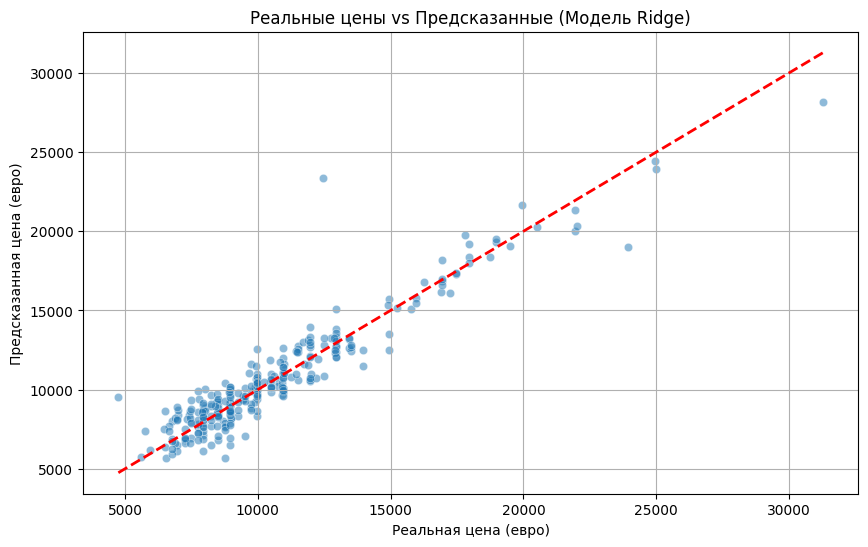

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_final = models["Ridge"].predict(X_test_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_final, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title('Реальные цены vs Предсказанные (Модель Ridge)')
plt.xlabel('Реальная цена (евро)')
plt.ylabel('Предсказанная цена (евро)')
plt.grid(True)
plt.show()

## 7. Итоговый вывод (Summary)

В ходе выполнения работы была построена и проанализирована модель машинного обучения для прогнозирования стоимости автомобилей **Toyota Corolla**.

### Основные результаты:
* **Качество прогноза:** Лучший результат показала модель **Ridge**, достигнув коэффициента детерминации **$R^2 \approx 0.89$**. Это говорит о том, что модель объясняет почти 89% вариативности целевой переменной, что является высоким показателем точности.
* **Ключевые факторы:** Наибольшее влияние на формирование цены оказали возраст автомобиля (`Age`) и его пробег (`KM`).
* **Эффективность признаков:** Использование группировки цветов (создание признака `Is_Basic_Color`) и кодирование типа топлива позволили сохранить информативность данных, избежав при этом избыточной сложности и «проклятия размерности».
* **Надежность модели:** Схожесть метрик (MAE, RMSE, $R^2$) у классической линейной регрессии и моделей с регуляризацией (Lasso, Ridge) на тестовой выборке подтверждает, что признаки подобраны оптимально. Модель демонстрирует хорошую обобщающую способность, не имеет признаков переобучения и готова к работе с новыми данными.